#### <span style="color: deepskyblue;">Analiza dotycząca oferowanych powierzchni nieruchomości w ujęciu geograficznym   </span>


In [125]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
import seaborn as sns
import missingno as msno
import plotly.express as px

%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

df = pd.read_csv("../data/apartments_clean.csv", sep=';', encoding="cp1250")
#df.head(1)

C:\Users\Grażyna\AppData\Local\Temp\ipykernel_11928\2722360184.py:12: DtypeWarning: Columns (0: address) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/apartments_clean.csv", sep=';', encoding="cp1250")


Skróty stref czasowych użyte w tabeli df_state:
- EST (Wschodnia), 
- CST (Centralna), 
- MST (Górska), 
- PST (Pacyficzna), 
- AKST (Alaska), 
- HST (Hawaje). 

Plik grupujący stany USA wg różnych kategorii pozyskany jest z pomocą AI ze strony U.S. Census Bureau (Biuro Spisu Ludności USA).</BR> 
Oznaczenie „Tak” w kolumnach <span style="color: deepskyblue;">Stan rolniczy</span>, <span style="color: deepskyblue;">Stan przemysłowy</span>, <span style="color: deepskyblue;">Ważny turystycznie</span> wskazuje,</BR> że dany sektor stanowi kluczowy, wyróżniający się filar gospodarki lub tożsamości stanu na tle reszty kraju 

In [126]:
df_state = pd.read_csv("../data/przypisanie_stanowUSA.csv", sep=';', encoding="cp1250")
df_state.head(1)

,Stan,Skrot,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie
0,Alabama,AL,South,CST / EST,Tak,Tak,Nie


In [127]:

# dołącz nazwę stanu
df = df.merge(
    df_state[['Skrot', 'Stan']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz region
df = df.merge(
    df_state[['Skrot', 'Region']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Strefa czasowa
df = df.merge(
    df_state[['Skrot', 'Strefa czasowa']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Stan rolniczy
df = df.merge(
    df_state[['Skrot', 'Stan rolniczy']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Stan przemyslowy
df = df.merge(
    df_state[['Skrot', 'Stan przemyslowy']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Wazny turystycznie
df = df.merge(
    df_state[['Skrot', 'Wazny turystycznie']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

#df.head(1)

In [129]:
df1 = df[(df["square_feet"] <= 300)]
df1["bin_square_feet"] = pd.cut(
    df1["square_feet"],
    bins=[0, 200, 250, 300, float("inf")],
    labels=["0-200", "200-250", "250-300", "300+"]
)
#df1.head(3)
#df1.to_csv('D:\\tmp\\df1.csv', sep=';', index=False, encoding='utf-8')

In [ ]:
df2 = df[(df["square_feet"] > 300) & ( df["square_feet"] <= 2100) ]
df2["bin_square_feet"] = pd.cut(
    df2["square_feet"],
    bins=[300,500, 700, 1000, 1500, 2000, 2100, float("inf")],
    labels=["do 500", " do 700", " do 1000", "do 1500",
            " do 2000","do 2100", "2100+"]
)
#df2.head(3)

In [137]:
df3 = df[(df["square_feet"] > 2100)]
df3["bin_square_feet"] = pd.cut(
    df3["square_feet"],
    bins=[2100,2500,3000, 4000, 5000, 10000, float("inf")],
    labels=["do 2500", " do 3000", " do 4000", "do 5000","do 10000", "10000+"]
)
#df3.head(3)

Rozkład wartości powierzchni według Regionu USA dla różnych grup nieruchomości

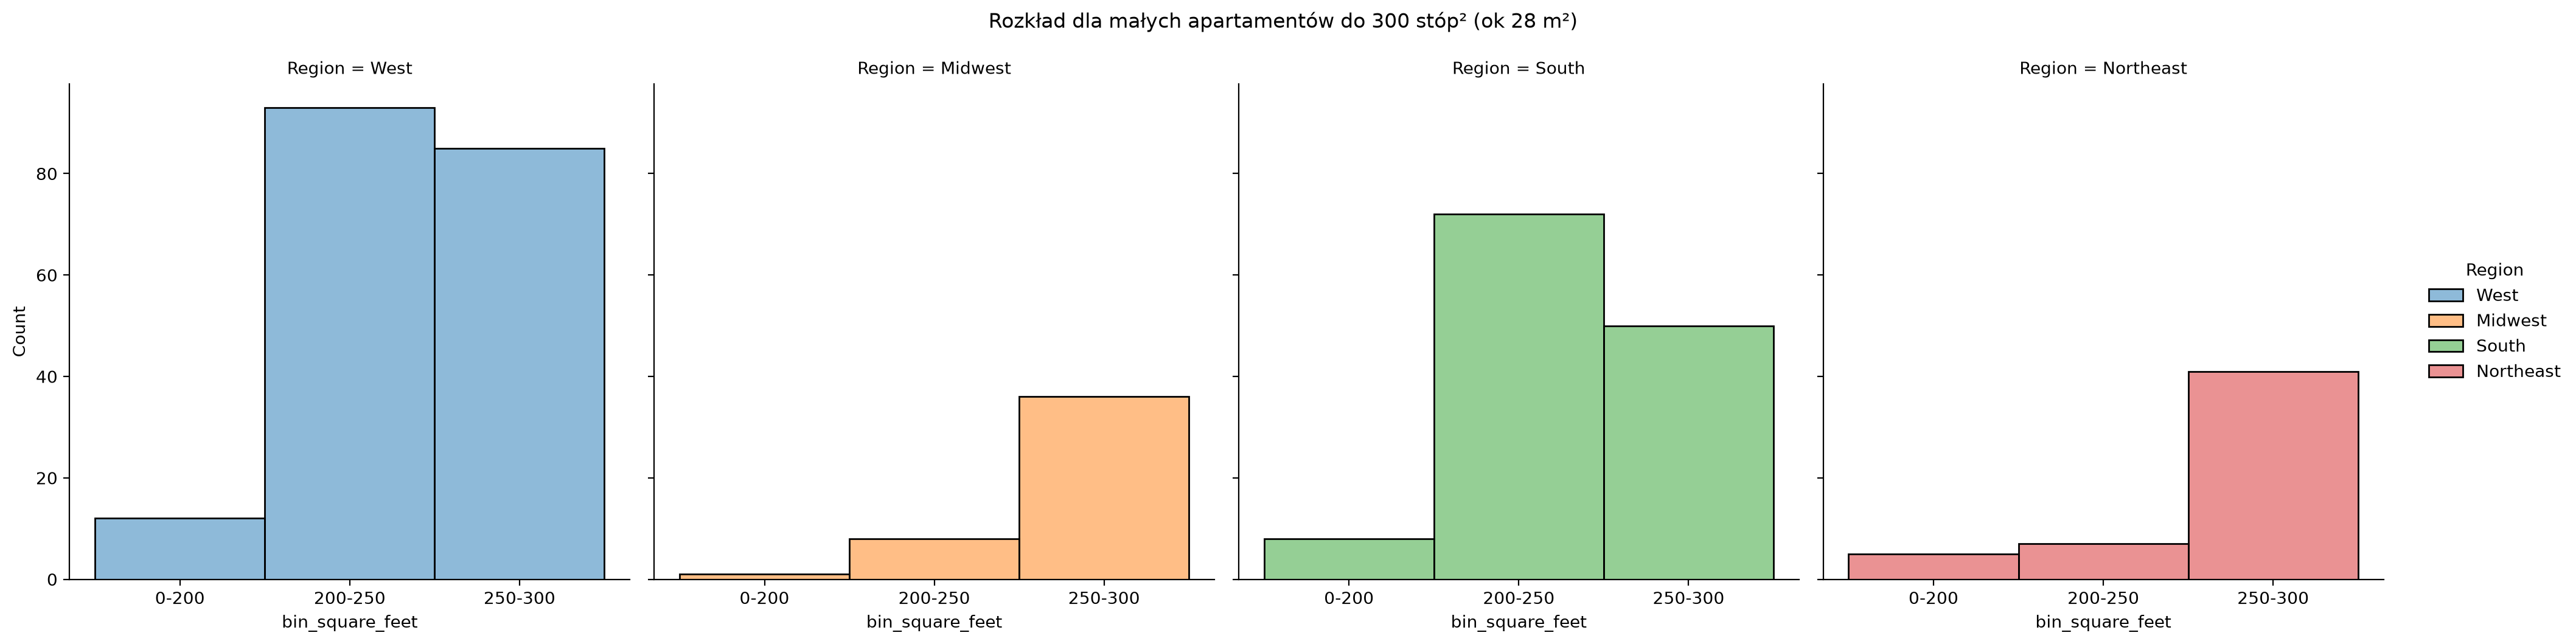

In [132]:
sns.displot(
    data=df1,
    x="bin_square_feet",
    col="Region",
    hue="Region"    
)
plt.suptitle("Rozkład dla małych apartamentów do 300 stóp² (ok 28 m²)", y=1.05)
plt.show()

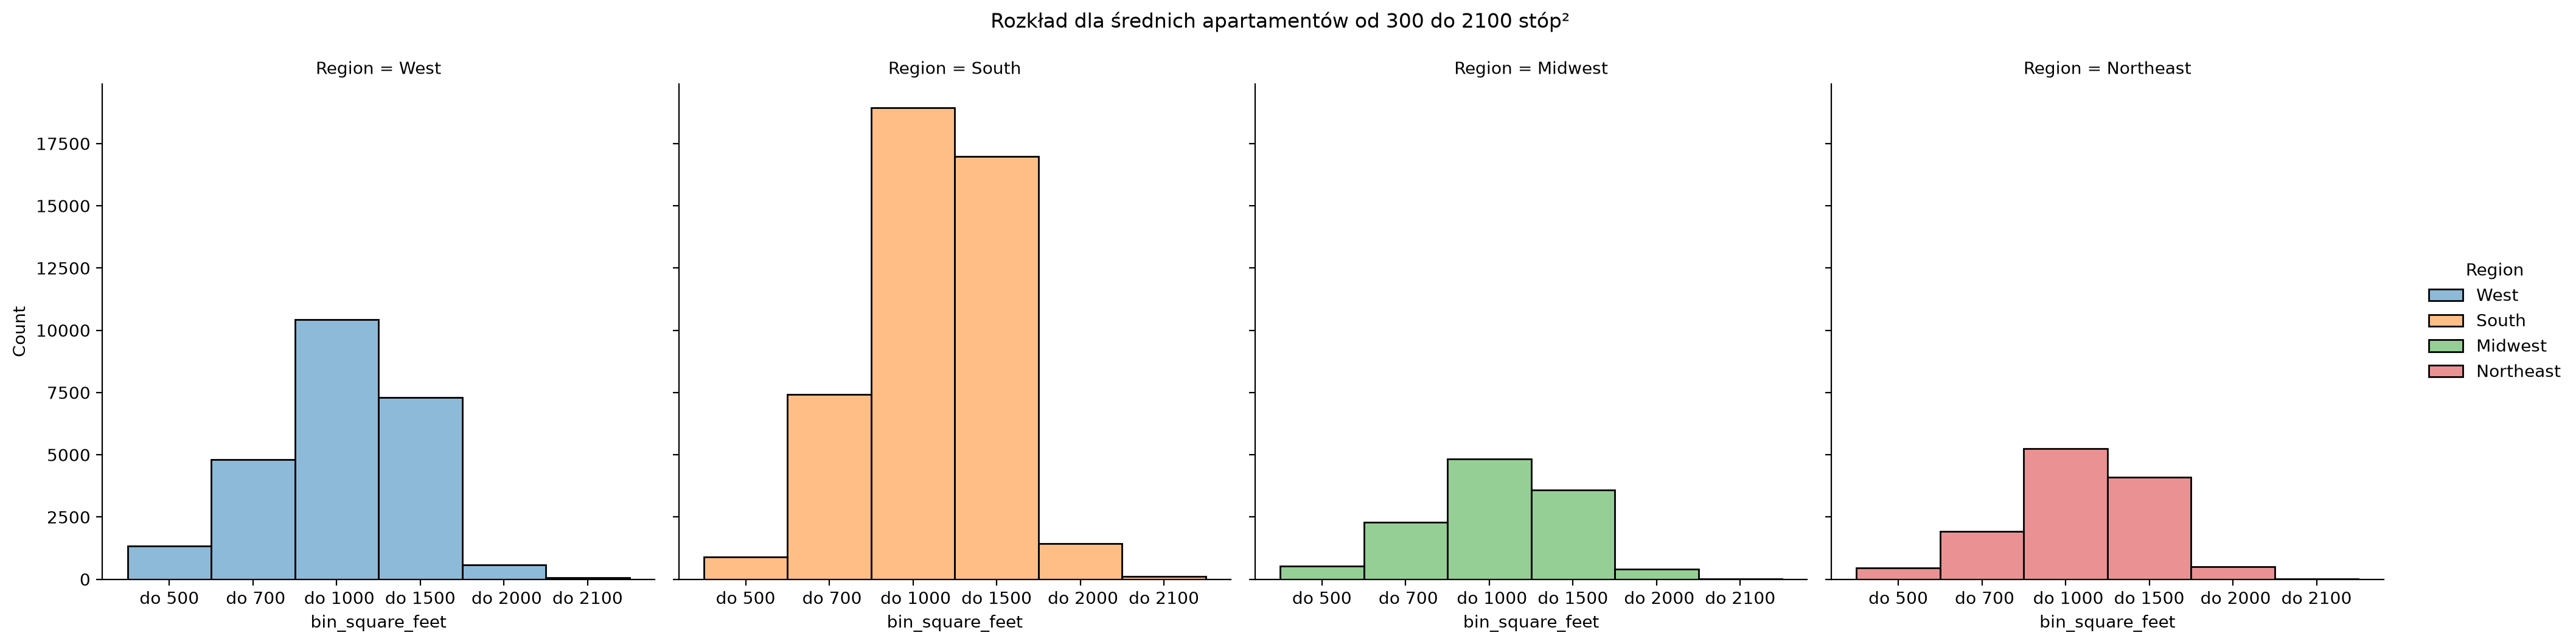

In [135]:
sns.displot(
    data=df2,
    x="bin_square_feet",
    col="Region",
    hue="Region"    
)

plt.suptitle("Rozkład dla średnich apartamentów od 300 do 2100 stóp² ", y=1.05)
plt.show()


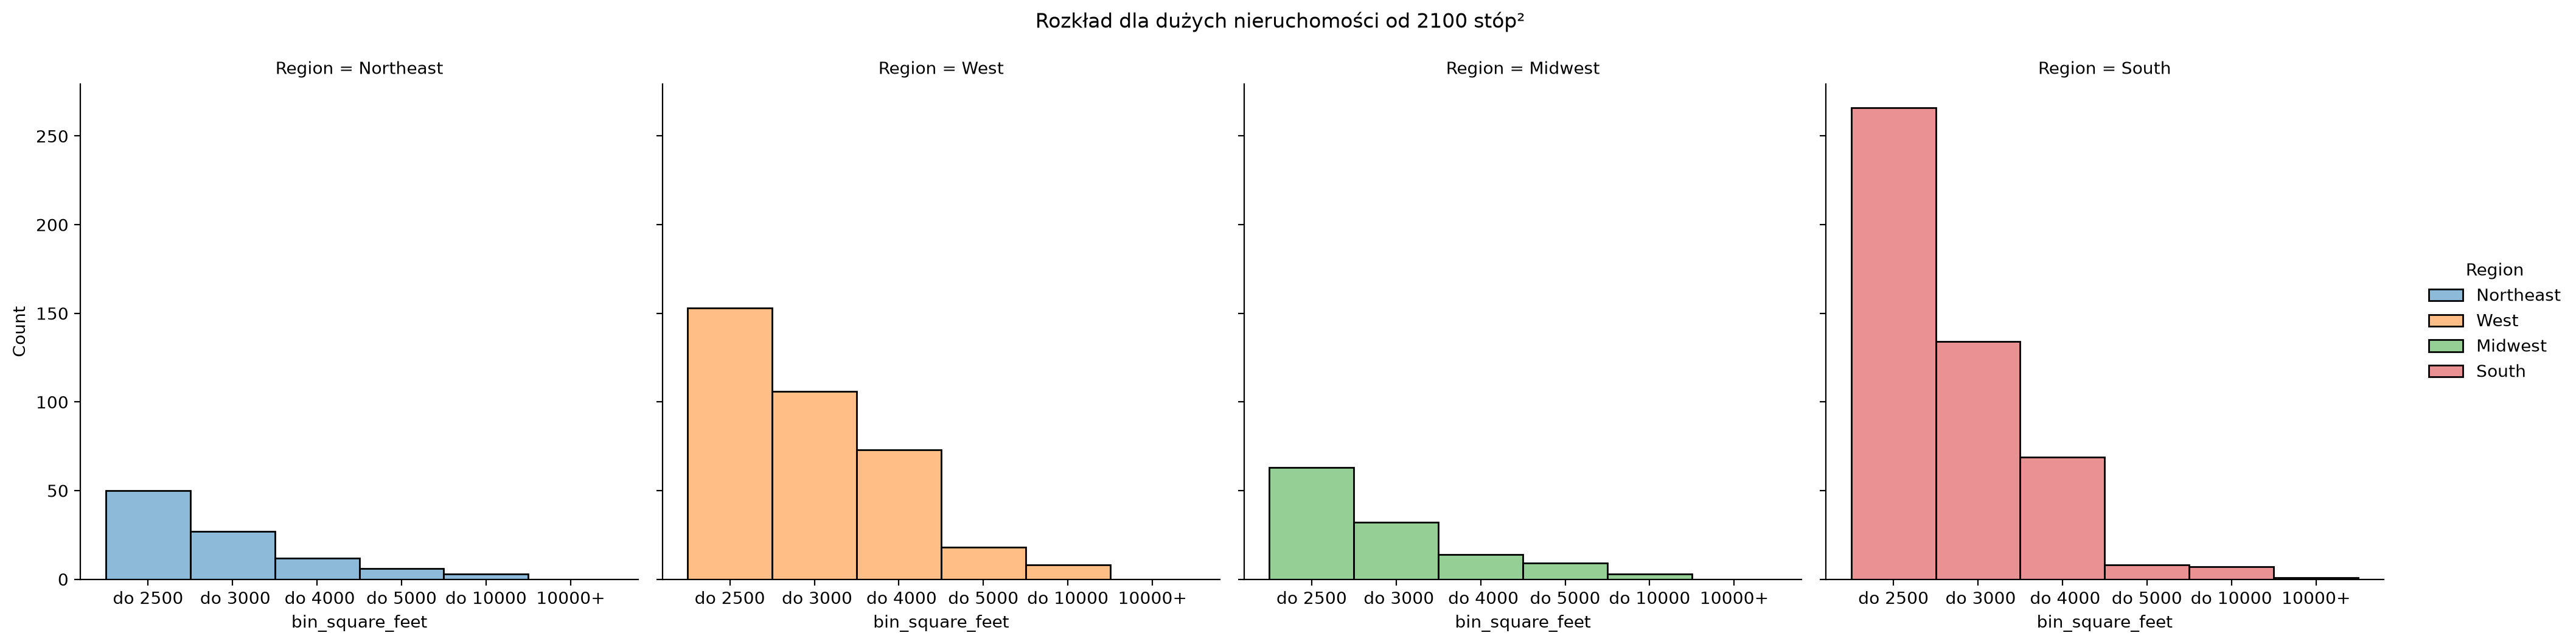

In [138]:
sns.displot(
    data=df3,
    x="bin_square_feet",
    col="Region",
    hue="Region"    
)

plt.suptitle("Rozkład dla dużych nieruchomości od 2100 stóp² ", y=1.05)
plt.show()